# Intelligent Spam Classification & Threat Triage Platform
## Notebook 02 — Classical ML Baseline

This notebook establishes the first machine-learning benchmark for the **Intelligent Spam Classification & Threat Triage Platform**.

The baseline intentionally uses a simple and explainable architecture:

**Canonical Email → TF-IDF → Logistic Regression → BENIGN / THREAT**

The objective is not to build the final detection system here. The objective is to create a strong, reproducible benchmark against which later approaches can be compared:

- Classical ML
- Gemini-only reasoning
- Hybrid ML + Agentic AI
- Human-in-the-loop threat triage

### Key Principles

- Use the reusable canonical data pipeline from `src/threat_triage/data_loader.py`.
- Use `combined_text` as the baseline model input.
- Treat `THREAT` (`label_id = 1`) as the positive class.
- Fit feature extraction **only on training data**.
- Use the validation set for model analysis and threshold selection.
- Keep the supplied test split locked until the final evaluation section.
- Evaluate security-specific trade-offs, not accuracy alone.

## 1. Environment Setup

The notebook is designed for Google Colab and assumes the repository structure contains:

```text
src/
└── threat_triage/
    ├── __init__.py
    └── data_loader.py
```

and:

```text
tests/
notebooks/
artifacts/
```

If running from a cloned Git repository, ensure the repository root is the current working directory.

In [1]:
# Cell 1 — Install required packages

!pip -q install datasets pyarrow pandas numpy scikit-learn matplotlib joblib

In [2]:
# Cell 2 — Imports

from __future__ import annotations

import json
import re
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42

print("Imports loaded successfully.")

Imports loaded successfully.


## 2. Repository / Import Configuration

The project uses a `src/` layout. Add the source directory to Python's import path when running interactively in Colab.

This is only notebook bootstrap logic. In the local repository, the preferred development setup is eventually:

```bash
pip install -e .
```

In [3]:
# Cell 3 — Configure project import path

PROJECT_ROOT = Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if SRC_PATH.exists():
    src_string = str(SRC_PATH.resolve())

    if src_string not in sys.path:
        sys.path.insert(0, src_string)

print("Project root :", PROJECT_ROOT)
print("Source path  :", SRC_PATH.resolve() if SRC_PATH.exists() else "NOT FOUND")

Project root : /content
Source path  : /content/src


In [4]:
# Cell 4 — Import reusable canonical data loader

from threat_triage.data_loader import (
    CANONICAL_COLUMNS,
    LABEL_MAP,
    DatasetSplits,
    get_train_validation_test,
)

print("Data loader imported successfully.")
print("Canonical labels:", LABEL_MAP)

Data loader imported successfully.
Canonical labels: {0: 'BENIGN', 1: 'THREAT'}


## 3. Load Canonical Dataset

The raw Hugging Face schema must not leak into the ML code.

All downstream components consume the canonical project schema:

```text
message_id
subject
body
sender
receiver
timestamp
has_url
source_dataset
original_label
canonical_label
label_id
combined_text
```

The original Hugging Face test split remains untouched.
Only the original training split is divided into **train** and **validation**.

In [5]:
# Cell 5 — Load train / validation / locked test

splits = get_train_validation_test(
    validation_size=0.20,
    random_state=RANDOM_STATE,
)

train_df = splits.train
validation_df = splits.validation
test_df = splits.test

print("Train      :", train_df.shape)
print("Validation :", validation_df.shape)
print("Test       :", test_df.shape)

README.md:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B /  184MB            

train.parquet: downloading bytes:           |  0.00B            

test.parquet: reconstructing file:   0%|          |  0.00B / 22.7MB            

test.parquet: downloading bytes:           |  0.00B            

eval.parquet: reconstructing file:   0%|          |  0.00B / 22.7MB            

eval.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/162413 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/40604 [00:00<?, ? examples/s]

Train      : (129930, 12)
Validation : (32483, 12)
Test       : (40604, 12)


## 4. Validate Dataset Splits

Before modeling, verify:

- canonical schema consistency,
- label balance,
- absence of missing model input,
- distinct split sizes.

The validation and test sets must never be used to fit TF-IDF vocabulary or model coefficients.

In [6]:
# Cell 6 — Validate canonical columns

assert list(train_df.columns) == CANONICAL_COLUMNS
assert list(validation_df.columns) == CANONICAL_COLUMNS
assert list(test_df.columns) == CANONICAL_COLUMNS

print("Canonical schema validation: PASSED")

Canonical schema validation: PASSED


In [7]:
# Cell 7 — Validate model input and labels

for split_name, dataframe in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    print("\n" + "=" * 60)
    print(split_name.upper())

    print("Rows:", len(dataframe))
    print("Missing combined_text:", dataframe["combined_text"].isna().sum())
    print("Empty combined_text:", (dataframe["combined_text"].str.len() == 0).sum())

    print("\nLabel distribution:")
    print(
        dataframe["canonical_label"]
        .value_counts(normalize=True)
        .round(4)
    )


TRAIN
Rows: 129930
Missing combined_text: 0
Empty combined_text: 0

Label distribution:
canonical_label
BENIGN    0.5354
THREAT    0.4646
Name: proportion, dtype: float64

VALIDATION
Rows: 32483
Missing combined_text: 0
Empty combined_text: 0

Label distribution:
canonical_label
BENIGN    0.5354
THREAT    0.4646
Name: proportion, dtype: float64

TEST
Rows: 40604
Missing combined_text: 0
Empty combined_text: 0

Label distribution:
canonical_label
BENIGN    0.5354
THREAT    0.4646
Name: proportion, dtype: float64


In [8]:
# Cell 8 — Check message ID overlap across splits

train_ids = set(train_df["message_id"])
validation_ids = set(validation_df["message_id"])
test_ids = set(test_df["message_id"])

print("Train ∩ Validation :", len(train_ids & validation_ids))
print("Train ∩ Test       :", len(train_ids & test_ids))
print("Validation ∩ Test  :", len(validation_ids & test_ids))

Train ∩ Validation : 69
Train ∩ Test       : 78
Validation ∩ Test  : 18


## 5. Baseline Modeling Strategy

The baseline uses:

### Feature Extraction
**TF-IDF (Term Frequency–Inverse Document Frequency)**

Configuration:

- lowercase text
- word-level tokens
- unigrams + bigrams
- minimum document frequency to remove extremely rare terms
- maximum feature cap for predictable memory usage
- sublinear term-frequency scaling

### Classifier
**Logistic Regression**

Why this baseline?

- strong for sparse text classification,
- fast compared with transformer training,
- interpretable coefficients,
- probability output for threshold analysis,
- easy to deploy and reproduce.

This model is intentionally simple. Its role is to define the benchmark the later Agentic AI architecture must justify improving upon.

In [9]:
# Cell 9 — Define baseline configuration

TFIDF_CONFIG = {
    "lowercase": True,
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.98,
    "max_features": 75000,
    "sublinear_tf": True,
    "strip_accents": "unicode",
}

LOGISTIC_CONFIG = {
    "C": 1.0,
    "max_iter": 1000,
    "solver": "liblinear",
    "random_state": RANDOM_STATE,
}

print("TF-IDF configuration:")
print(TFIDF_CONFIG)

print("\nLogistic Regression configuration:")
print(LOGISTIC_CONFIG)

TF-IDF configuration:
{'lowercase': True, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.98, 'max_features': 75000, 'sublinear_tf': True, 'strip_accents': 'unicode'}

Logistic Regression configuration:
{'C': 1.0, 'max_iter': 1000, 'solver': 'liblinear', 'random_state': 42}


## 6. TF-IDF + Logistic Regression Pipeline

Using a scikit-learn `Pipeline` prevents accidental train/validation leakage because the vectorizer is fit together with the classifier only on the training set.

In [10]:
# Cell 10 — Build baseline pipeline

baseline_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(**TFIDF_CONFIG),
        ),
        (
            "classifier",
            LogisticRegression(**LOGISTIC_CONFIG),
        ),
    ]
)

baseline_model

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.98, max_features=75000, min_df=2,
                                 ngram_range=(1, 2), strip_accents='unicode',
                                 sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])

## 7. Train the Baseline

Only `train_df` is used here.

Neither validation nor locked test data participates in:

- vocabulary creation,
- inverse-document-frequency estimation,
- coefficient fitting.

In [11]:
# Cell 11 — Prepare training data

X_train = train_df["combined_text"]
y_train = train_df["label_id"]

X_validation = validation_df["combined_text"]
y_validation = validation_df["label_id"]

print("Training samples   :", len(X_train))
print("Validation samples :", len(X_validation))

Training samples   : 129930
Validation samples : 32483


In [12]:
# Cell 12 — Train model

baseline_model.fit(
    X_train,
    y_train,
)

print("Baseline model training: COMPLETE")

Baseline model training: COMPLETE


In [13]:
# Cell 13 — Inspect fitted vocabulary size

vectorizer = baseline_model.named_steps["tfidf"]
classifier = baseline_model.named_steps["classifier"]

print("Vocabulary size :", len(vectorizer.vocabulary_))
print("Classes         :", classifier.classes_)
print("Coefficient shape:", classifier.coef_.shape)

Vocabulary size : 75000
Classes         : [0 1]
Coefficient shape: (1, 75000)


# 8. Validation-Set Evaluation

The validation set is now used to evaluate the default classifier behavior.

The default scikit-learn decision threshold is:

`P(THREAT) >= 0.50`

Metrics include:

- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC

For security systems, **Recall, False Negative Rate, and Precision** are particularly important because the costs of missed threats and false alarms are asymmetric.

In [14]:
# Cell 14 — Validation predictions

validation_probability = baseline_model.predict_proba(
    X_validation
)[:, 1]

validation_prediction_05 = (
    validation_probability >= 0.50
).astype(int)

print("Validation predictions generated.")

Validation predictions generated.


In [15]:
# Cell 15 — Reusable classification metrics

def classification_metrics(
    y_true,
    y_pred,
    y_probability,
):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc": average_precision_score(y_true, y_probability),
    }


validation_metrics_05 = classification_metrics(
    y_validation,
    validation_prediction_05,
    validation_probability,
)

pd.Series(validation_metrics_05).round(4)

,0
accuracy,0.9826
precision,0.9789
recall,0.9838
f1,0.9813
roc_auc,0.9982
pr_auc,0.9979


In [16]:
# Cell 16 — Classification report

print(
    classification_report(
        y_validation,
        validation_prediction_05,
        target_names=["BENIGN", "THREAT"],
        digits=4,
    )
)

              precision    recall  f1-score   support

      BENIGN     0.9859    0.9816    0.9837     17390
      THREAT     0.9789    0.9838    0.9813     15093

    accuracy                         0.9826     32483
   macro avg     0.9824    0.9827    0.9825     32483
weighted avg     0.9826    0.9826    0.9826     32483



## 8.1 Confusion Matrix

For the positive THREAT class:

```text
TN = correctly allowed benign messages
FP = benign messages incorrectly flagged as threats
FN = threats incorrectly classified as benign
TP = correctly detected threats
```

False negatives are especially important because they represent threats that could reach users.

In [17]:
# Cell 17 — Confusion matrix values

tn, fp, fn, tp = confusion_matrix(
    y_validation,
    validation_prediction_05,
).ravel()

confusion_summary = pd.DataFrame(
    {
        "Metric": [
            "True Negative",
            "False Positive",
            "False Negative",
            "True Positive",
        ],
        "Count": [tn, fp, fn, tp],
    }
)

confusion_summary

,Metric,Count
0,True Negative,17070
1,False Positive,320
2,False Negative,245
3,True Positive,14848


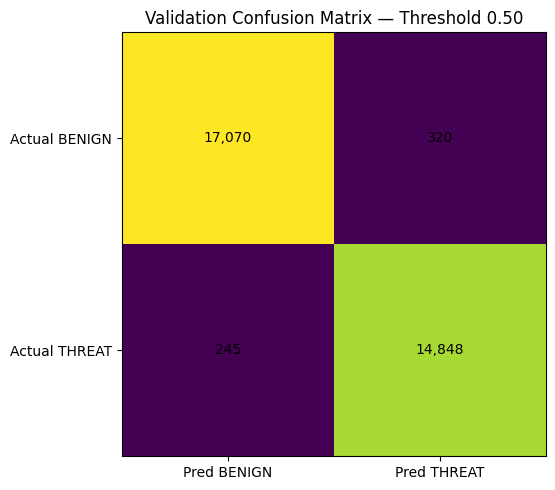

In [18]:
# Cell 18 — Plot confusion matrix

matrix = np.array([
    [tn, fp],
    [fn, tp],
])

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(matrix)

ax.set_xticks([0, 1], labels=["Pred BENIGN", "Pred THREAT"])
ax.set_yticks([0, 1], labels=["Actual BENIGN", "Actual THREAT"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center")

ax.set_title("Validation Confusion Matrix — Threshold 0.50")
plt.tight_layout()
plt.show()

# 9. Security-Oriented Metrics

Generic classification metrics are not enough for enterprise email security.

We explicitly calculate:

### False Positive Rate (FPR)

Fraction of legitimate mail incorrectly classified as threat.

High FPR can cause:

- unnecessary quarantine,
- user frustration,
- analyst workload,
- business disruption.

### False Negative Rate (FNR)

Fraction of actual threats incorrectly classified as benign.

High FNR can allow:

- phishing,
- credential theft,
- malicious links,
- social engineering

to reach users.

In [19]:
# Cell 19 — Security-specific rates

def security_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0.0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        "false_positive_rate": false_positive_rate,
        "false_negative_rate": false_negative_rate,
        "specificity": specificity,
    }


validation_security_05 = security_metrics(
    y_validation,
    validation_prediction_05,
)

pd.Series(validation_security_05)

,0
true_negative,17070.000000
false_positive,320.000000
false_negative,245.000000
true_positive,14848.000000
false_positive_rate,0.018401
false_negative_rate,0.016233
specificity,0.981599


## 9.1 ROC Curve

ROC analysis shows how True Positive Rate changes against False Positive Rate as the decision threshold moves.

ROC-AUC is useful, but it should not be interpreted alone. Security systems also require explicit threshold and error-cost analysis.

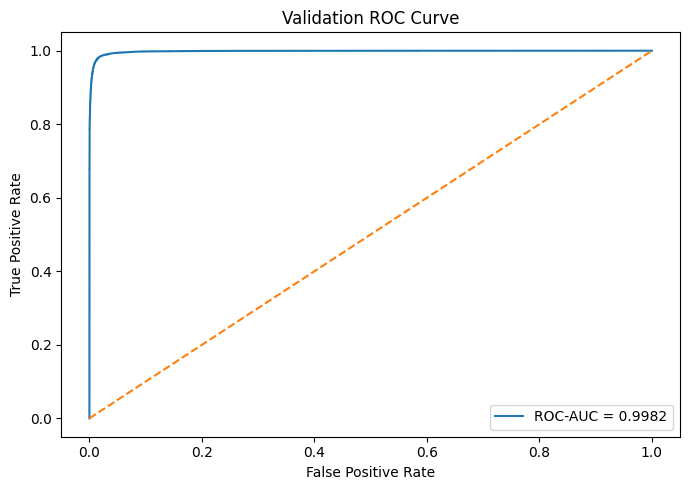

In [20]:
# Cell 20 — ROC curve

fpr, tpr, roc_thresholds = roc_curve(
    y_validation,
    validation_probability,
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, label=f"ROC-AUC = {validation_metrics_05['roc_auc']:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Validation ROC Curve")
ax.legend()

plt.tight_layout()
plt.show()

## 9.2 Precision–Recall Curve

Precision–Recall analysis is particularly useful when evaluating threat detection because it exposes the trade-off between:

- detecting more threats,
- generating more false alarms.

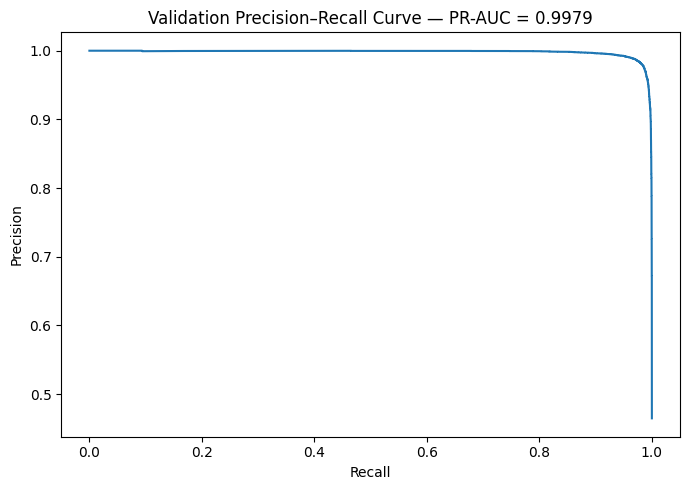

In [21]:
# Cell 21 — Precision-recall curve

pr_precision, pr_recall, pr_thresholds = precision_recall_curve(
    y_validation,
    validation_probability,
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(pr_recall, pr_precision)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(
    f"Validation Precision–Recall Curve — PR-AUC = {validation_metrics_05['pr_auc']:.4f}"
)

plt.tight_layout()
plt.show()

# 10. Per-Source Dataset Performance

The EDA showed materially different threat rates across source corpora.

Therefore aggregate performance alone is insufficient.

Evaluate the baseline separately for:

- TREC-05
- TREC-06
- TREC-07
- CEAS-08
- Enron
- Assassin
- Ling

This helps identify whether the classifier performs well only because it has learned dataset-specific artifacts.

In [22]:
# Cell 22 — Add validation predictions to analysis copy

validation_analysis = validation_df.copy()

validation_analysis["threat_probability"] = validation_probability
validation_analysis["prediction_05"] = validation_prediction_05

validation_analysis.head()

,message_id,subject,body,sender,receiver,timestamp,has_url,source_dataset,original_label,canonical_label,label_id,combined_text,threat_probability,prediction_05
0,1fc61170337e64981f84952aeec94741455b4a796b4b8520242b5bf01b7e9eca,RE:,"I'm glad you approve..I was hoping you would. \n\n -----Original Message-----\nFrom: \tMaggi, Mike \nSent:\tThursday, October 25, 2001 11:46 AM\nTo:\tRyba...","""Rybarski, Amanda"" <Amanda.Rybarski@ENRON.com>","""Maggi, Mike"" <Mike.Maggi@ENRON.com>",2001-10-25 16:45:59,False,TREC-05,0,BENIGN,0,"RE:\n\nI'm glad you approve..I was hoping you would. \n\n -----Original Message-----\nFrom: \tMaggi, Mike \nSent:\tThursday, October 25, 2001 11:46 AM\nTo...",0.013942,0
1,c17f1388ae314ff14b9ffac8b8e6f138d5018c2f5e6a6cf964bb8d248a12f9be,[Mhln] Competitive rates,"characteristics of a person, place or object in a form which can intrusive nature of the electronic net, a net we could all be may be too much to ask or ho...",Chance Oneill <kuleasings@vitalpethealth.com>,mhln@mhlearningnetwork.com,2007-05-13 02:12:16,False,TREC-07,1,THREAT,1,"[Mhln] Competitive rates\n\ncharacteristics of a person, place or object in a form which can intrusive nature of the electronic net, a net we could all be ...",0.876581,1
2,6200d11f8b046eb656a32995032a62d0356e777a5599de3b322e3b9bfc2ad791,"[UAI] CFP: CICLing-2008 - NLP, Computational Linguistics; Springer LNCS + IEEE",CICLing-2008\n\n 9th International Conference\n on Intelligent Text Processing\n and Computational Linguistics\n\n February 17-2...,"""Alexander Gelbukh (CICLing-2008)"" <fwj2317t@cicling.org>","""'NLP and Comp. Linguistics'"" <aqz4438d@cicling.org>",2008-08-08 04:52:11,True,CEAS-08,0,BENIGN,0,"[UAI] CFP: CICLing-2008 - NLP, Computational Linguistics; Springer LNCS + IEEE\n\nCICLing-2008\n\n 9th International Conference\n on Intellige...",0.044986,0
3,cd879b81b3ff9b3134d3b236849b2f73ea1e2b4f4498e25440a94a70b187396a,Important Membership Information,Dear richard766\n\nWelcome to NYTimes.com! \n\nWe are delighted that you have decided to become a member \nof our community. As a member you now have comple...,"""NYTimes.com"" <announce@inbox.nytimes.com>",richard.ring@enron.com,2002-01-28 22:05:35,True,TREC-05,0,BENIGN,0,Important Membership Information\n\nDear richard766\n\nWelcome to NYTimes.com! \n\nWe are delighted that you have decided to become a member \nof our commun...,0.151252,0
4,5bd61be42de9c06d3b4592a680101d57fc74e8396455b8a1a34403cb24e4d439,CNN Alerts: My Custom Alert,"CNN Alerts: My Custom Alert\n\n\n\n\n\n\n \n\n\n\nAlert Name: My Custom Alert\nWorld's smallest snake found\n\nFri, 8 Aug 2008 18:32:31 +0900\n\nFULL STORY\...",CNN Alerts <oresteia_1995@waxmanandassociates.com>,user7-ext1@gvc.ceas-challenge.cc,2008-08-08 09:36:41,False,CEAS-08,1,THREAT,1,"CNN Alerts: My Custom Alert\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n \n\n\n\nAlert Name: My Custom Alert\nWorld's smallest snake found\n\nFri, 8 Aug 200...",0.985666,1


In [23]:
# Cell 23 — Per-source metrics helper

def evaluate_group(group):
    y_true = group["label_id"].to_numpy()
    y_pred = group["prediction_05"].to_numpy()
    y_prob = group["threat_probability"].to_numpy()

    result = {
        "rows": len(group),
        "threat_rate": y_true.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if len(np.unique(y_true)) == 2:
        result["roc_auc"] = roc_auc_score(y_true, y_prob)
        result["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        result["roc_auc"] = np.nan
        result["pr_auc"] = np.nan

    security = security_metrics(y_true, y_pred)
    result["false_positive_rate"] = security["false_positive_rate"]
    result["false_negative_rate"] = security["false_negative_rate"]

    return pd.Series(result)

In [43]:
# Cell 24 — Per-source validation performance

source_performance = (
    validation_analysis
    .groupby("source_dataset", group_keys=False)
    .apply(
        evaluate_group,
        include_groups=False,
    )
    .sort_values("f1", ascending=False)
)

source_performance.round(4)

,rows,threat_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,false_negative_rate
source_dataset,,,,,,,,,,
CEAS-08,6344.0,0.5525,0.9887,0.9815,0.9983,0.9898,0.9995,0.9996,0.0232,0.0017
TREC-07,8427.0,0.5428,0.9853,0.9958,0.9770,0.9863,0.9990,0.9988,0.0049,0.0230
Enron,4759.0,0.4682,0.9834,0.9799,0.9847,0.9823,0.9984,0.9982,0.0178,0.0153
TREC-05,8984.0,0.4224,0.9774,0.9680,0.9789,0.9734,0.9973,0.9966,0.0237,0.0211
Ling,443.0,0.1535,0.9910,0.9571,0.9853,0.9710,0.9993,0.9966,0.0080,0.0147
TREC-06,2587.0,0.2482,0.9811,0.9419,0.9844,0.9627,0.9977,0.9938,0.0201,0.0156
Assassin,939.0,0.2993,0.9638,0.9158,0.9680,0.9412,0.9934,0.9860,0.0380,0.0320


# 11. Error Analysis

A security classifier must be inspected at the record level.

Two error classes matter:

### False Positive
A BENIGN message is incorrectly classified as THREAT.

Potential impact:

- legitimate business email quarantined,
- user dissatisfaction,
- analyst workload.

### False Negative
A THREAT message is incorrectly classified as BENIGN.

Potential impact:

- phishing reaches users,
- credential compromise,
- malicious-link exposure,
- fraud or social-engineering success.

False negatives receive special attention in this project.

In [25]:
# Cell 25 — Safe preview helper

def sanitize_preview(value, max_chars=400):
    if value is None or (
        isinstance(value, float)
        and np.isnan(value)
    ):
        return ""

    text = str(value)

    text = text.replace("\r", " ").replace("\n", " ")

    text = re.sub(
        r"(?i)https?://",
        lambda match: (
            "hxxps://"
            if match.group(0).lower().startswith("https")
            else "hxxp://"
        ),
        text,
    )

    text = re.sub(r"\s+", " ", text).strip()

    return (
        text[:max_chars] + "..."
        if len(text) > max_chars
        else text
    )

In [26]:
# Cell 26 — False positives

false_positives = validation_analysis[
    (validation_analysis["label_id"] == 0)
    & (validation_analysis["prediction_05"] == 1)
].copy()

false_positives = false_positives.sort_values(
    "threat_probability",
    ascending=False,
)

print("False positives:", len(false_positives))

display_columns = [
    "source_dataset",
    "subject",
    "threat_probability",
    "body",
]

fp_preview = false_positives[
    display_columns
].head(10).copy()

fp_preview["subject"] = fp_preview["subject"].apply(
    lambda x: sanitize_preview(x, 150)
)

fp_preview["body"] = fp_preview["body"].apply(
    lambda x: sanitize_preview(x, 400)
)

fp_preview

False positives: 320


,source_dataset,subject,threat_probability,body
14980,TREC-07,"""Tarzan of the Apes"" for Monday April 23, 2007",0.996128,"FREE Ezine from ArcaMax, Inc. More from ArcaMax.com! Funnies | Puzzle Games | Quizzes | Unsubscribe Chat About Your Favorite Books www.ArcaMax.com | News | ..."
29017,TREC-06,See where your Competion is advertising,0.982770,"Are your clients: Travelers, Vacationers or Timeshare Owners? TVC...the Timeshare Vacation Club is where YOUR ADS should be! 100% Satisfaction GUARANTEED! T..."
4703,TREC-07,"[Reform] Photoshop, Windows, Office",0.971557,"OEM means Original Equipment Manufacturer. So OEM is synonym for lowest price. OEM software means no CD/DVD, no packing case, no booklets and no overhead co..."
28211,TREC-05,You received a PassionUp Greeting Page!,0.959827,Click here for a FREE GIFT! To: Dana Davis at dana.davis@enron.com From: Cheryl Sumbler at sumwil32@earthlink.net GOD IS GOOD ALL THE TIME IN SPITE OF OURSE...
7327,Assassin,"Adam dont job for no one, see.",0.949277,"A groys gesheft zol er hobn mit shroyre vus er hot, zol men bay im nit fregn, un vos men fregt zol er nisht hobn, and if that aint the truth nutin is."
8220,CEAS-08,FW:,0.943394,"Nouvelle cuisine, n.: French for ""not enough food"". Continental breakfast, n.: English for ""not enough food"". Tapas, n.: Spanish for ""not enough food"". Dim ..."
20883,TREC-05,A friend,0.929109,A simple friend has never seen you cry. A real friend has shoulders soggy from your tears. A simple friend doesn't know your parents' first names. A real fr...
25,CEAS-08,Weekend Sale - Up to 50% off!,0.928693,"To ensure emails are delivered, please add rngnsqsmjhgdegbirn@m.sharperimage.com to your address book. -----------------------------------------------------..."
14248,CEAS-08,Fwd:,0.927420,"---------- Forwarded message ---------- From: Živa Borak Date: Tue, 30 Nov 2004 19:41:54 +0100 Subject: To: Bistra Borak , Marko Bucar 1. Good: Your wife is..."
37,CEAS-08,"Translation Soft 6 by Systran 156, Pc or mac at 81%`discount",0.921626,quarkxpress passport 7.3 - 79 autodesk autocad electrical 2006 - 99 autodesk autocad electrical 2006 - 99 google sketchup pro 6 for mac - 59 ibm lotus smart...


In [27]:
# Cell 27 — False negatives

false_negatives = validation_analysis[
    (validation_analysis["label_id"] == 1)
    & (validation_analysis["prediction_05"] == 0)
].copy()

false_negatives = false_negatives.sort_values(
    "threat_probability",
    ascending=True,
)

print("False negatives:", len(false_negatives))

fn_preview = false_negatives[
    display_columns
].head(10).copy()

fn_preview["subject"] = fn_preview["subject"].apply(
    lambda x: sanitize_preview(x, 150)
)

fn_preview["body"] = fn_preview["body"].apply(
    lambda x: sanitize_preview(x, 400)
)

fn_preview

False negatives: 245


,source_dataset,subject,threat_probability,body
28348,TREC-05,ISDA's Annual Primary Contact Update (2001),0.006374,"ISDA® International Swaps and Derivatives Association, Inc. 600 Fifth Avenue, 27th Floor Rockefeller Center New York, NY 10020-2302 United States of America..."
24566,TREC-05,Power Plant Outages Information!,0.009059,Dear Colleague: Are you keeping up to date on plant outage information - nuclear or fossil - now that the Nuclear Regulatory Commission status report is no ...
25932,CEAS-08,Secondary CD/DVD Image Downloading,0.019130,"This is a repost. I just noticed that the original poster asked that it be mirrored to both groups. Since I'm working on it again, I'll add details. It is t..."
18051,TREC-05,"PowerMarketers.com Daily Power Report for June 25, 2002",0.027294,PowerMarketers.com Home - JobSite _____ The Power Marketing Association OnLine E-mail Us - Submit News Release The POWER REPORT...continuously updated onlin...
28311,CEAS-08,Re: [lwv-healthcare] Millions with Chronic illness go untreated - NY Times,0.027819,"Gert, There is an unsubscribe link on the bottom of every e-mail you get. You have to take yourself off of the list. I can't. Dick Mason - LWV of New Mexico..."
5257,TREC-06,Party for Prisoners of Conscience - PLEASE SEND TO YOUR ENTIRE CLUB,0.029873,Amnesty International and the Intercultural Resource Center are holding a party to raise money to support our efforts to release Yuri Bandazhevsky of Belaru...
7485,Enron,"cfp : int . conf . on web delivering of music , wedelmusic 2004 , barcelona , spain",0.042647,"sorry for any multiple reception of this message . if you do not want to receive further information about wedelmusic 2004 , please send back an email with ..."
8686,TREC-07,attire,0.044607,See Release Notes for the complete list. 4 Firewall Builder v2. 2 has been released Firewall Builder on Windows and Macintosh Firewall Builder v2. Object de...
26180,TREC-07,Free Shop Alert 6176,0.049335,"Latest Microsoft Windows News Unsubscribe | Edit my Alert Alerts for theorize@plg.uwaterloo.ca from ZDNet.com. Intel, Dell hold off on internal rollout of V..."
25768,TREC-07,Free Shop Alert 4498,0.050037,"Latest Microsoft Windows News Unsubscribe | Edit my Alert Alerts for the00@plg2.math.uwaterloo.ca from ZDNet.com. Intel, Dell hold off on internal rollout o..."


# 12. Model Explainability

One advantage of Logistic Regression over opaque models is that its learned coefficients can be inspected.

Positive coefficients contribute toward:

`THREAT`

Negative coefficients contribute toward:

`BENIGN`

This is **global model explainability**, not a complete explanation of any individual prediction.

Later, the Agentic AI layer will provide evidence-oriented explanations using multiple security signals.

In [28]:
# Cell 28 — Extract strongest coefficients

feature_names = vectorizer.get_feature_names_out()

coefficients = classifier.coef_[0]

feature_weights = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficients,
    }
)

strongest_threat_features = (
    feature_weights
    .sort_values("coefficient", ascending=False)
    .head(30)
)

strongest_benign_features = (
    feature_weights
    .sort_values("coefficient", ascending=True)
    .head(30)
)

print("Strongest THREAT-associated features:")
display(strongest_threat_features)

print("\nStrongest BENIGN-associated features:")
display(strongest_benign_features)

Strongest THREAT-associated features:


,feature,coefficient
74480,your,8.141120
47503,our,5.271375
31844,http,5.069005
37869,life,4.680148
30457,he,4.603507
16860,com,4.562257
30837,her,4.416666
40709,men,4.312680
2602,2005,4.151888
41601,money,4.068170



Strongest BENIGN-associated features:


,feature,coefficient
61589,thanks,-10.204116
73592,wrote,-10.154741
61986,the,-8.599808
23598,enron,-8.594279
4662,713,-7.063856
47185,org,-6.957477
66139,to,-6.897370
2422,2001,-6.823033
22779,edu,-6.645234
11000,attached,-5.967501


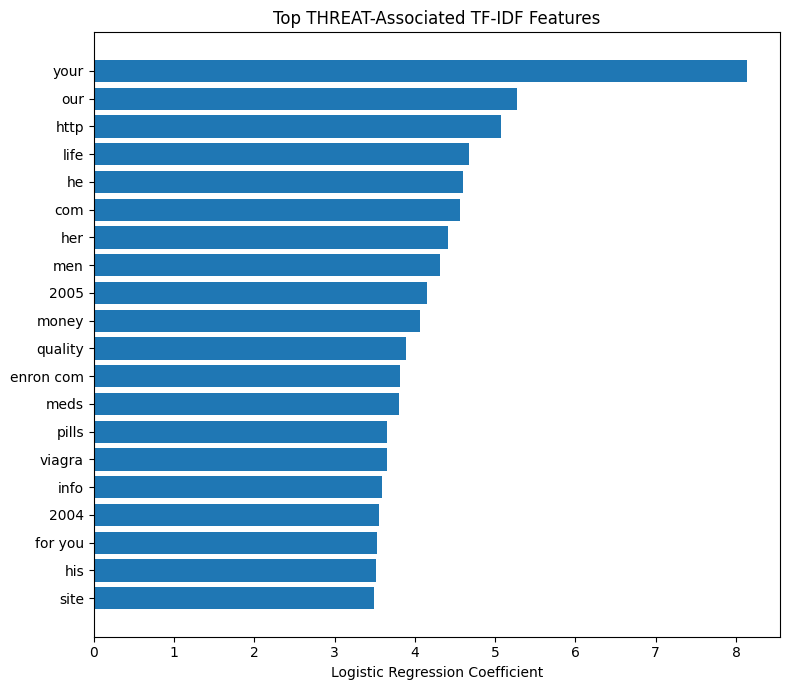

In [29]:
# Cell 29 — Plot top THREAT-associated features

plot_df = (
    strongest_threat_features
    .head(20)
    .sort_values("coefficient")
)

fig, ax = plt.subplots(figsize=(8, 7))

ax.barh(
    plot_df["feature"],
    plot_df["coefficient"],
)

ax.set_xlabel("Logistic Regression Coefficient")
ax.set_title("Top THREAT-Associated TF-IDF Features")

plt.tight_layout()
plt.show()

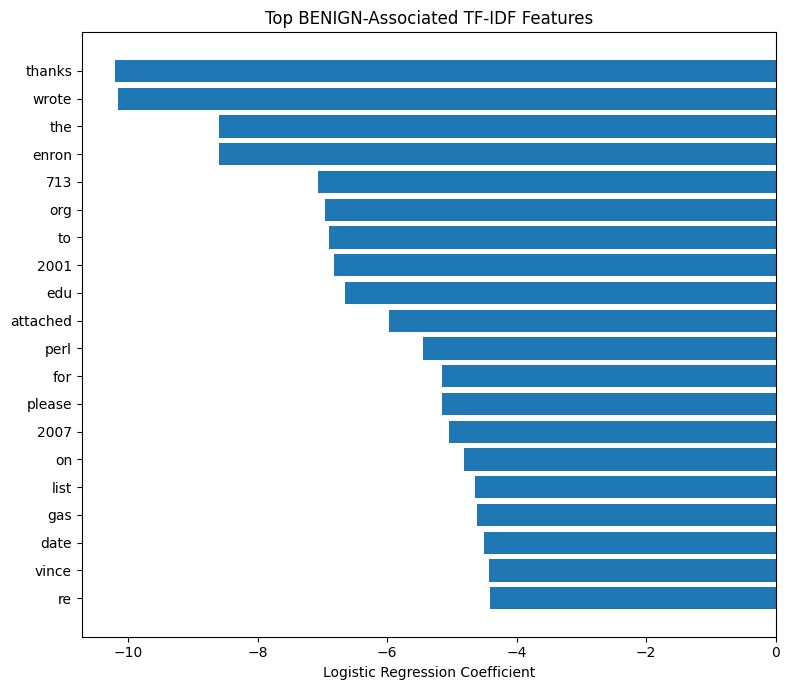

In [30]:
# Cell 30 — Plot top BENIGN-associated features

plot_df = (
    strongest_benign_features
    .head(20)
    .sort_values("coefficient", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 7))

ax.barh(
    plot_df["feature"],
    plot_df["coefficient"],
)

ax.set_xlabel("Logistic Regression Coefficient")
ax.set_title("Top BENIGN-Associated TF-IDF Features")

plt.tight_layout()
plt.show()

# 13. Decision-Threshold Analysis

The default threshold of `0.50` is not automatically the correct operating point for enterprise security.

Lower threshold:

- catches more threats,
- increases recall,
- may increase false positives.

Higher threshold:

- reduces false alarms,
- may allow more threats through.

The operating threshold must therefore be chosen from validation data according to security objectives.

In [31]:
# Cell 31 — Evaluate threshold grid

threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    prediction = (
        validation_probability >= threshold
    ).astype(int)

    metrics = classification_metrics(
        y_validation,
        prediction,
        validation_probability,
    )

    security = security_metrics(
        y_validation,
        prediction,
    )

    threshold_rows.append(
        {
            "threshold": round(float(threshold), 2),
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "false_positive_rate": security["false_positive_rate"],
            "false_negative_rate": security["false_negative_rate"],
            "false_positive": security["false_positive"],
            "false_negative": security["false_negative"],
        }
    )

threshold_table = pd.DataFrame(
    threshold_rows
)

threshold_table.round(4)

,threshold,precision,recall,f1,false_positive_rate,false_negative_rate,false_positive,false_negative
0,0.10,0.8661,0.9985,0.9276,0.1339,0.0015,2329,22
1,0.15,0.9035,0.9976,0.9482,0.0925,0.0024,1608,36
2,0.20,0.9270,0.9960,0.9603,0.0681,0.0040,1184,60
3,0.25,0.9418,0.9947,0.9676,0.0533,0.0053,927,80
4,0.30,0.9532,0.9931,0.9727,0.0423,0.0069,736,104
5,0.35,0.9617,0.9907,0.9760,0.0342,0.0093,595,141
6,0.40,0.9688,0.9890,0.9788,0.0276,0.0110,480,166
7,0.45,0.9744,0.9867,0.9805,0.0225,0.0133,391,201
8,0.50,0.9789,0.9838,0.9813,0.0184,0.0162,320,245
9,0.55,0.9826,0.9792,0.9809,0.0151,0.0208,262,314


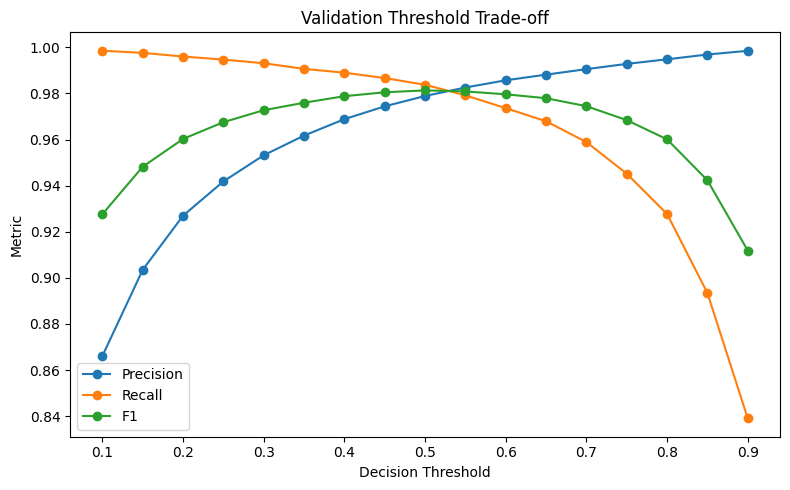

In [32]:
# Cell 32 — Plot threshold trade-offs

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    threshold_table["threshold"],
    threshold_table["precision"],
    marker="o",
    label="Precision",
)

ax.plot(
    threshold_table["threshold"],
    threshold_table["recall"],
    marker="o",
    label="Recall",
)

ax.plot(
    threshold_table["threshold"],
    threshold_table["f1"],
    marker="o",
    label="F1",
)

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Metric")
ax.set_title("Validation Threshold Trade-off")
ax.legend()

plt.tight_layout()
plt.show()

# 14. Select an Operating Threshold

For the first security baseline, use a **recall-oriented policy**:

> Find validation thresholds achieving at least 95% THREAT recall, then choose the one with the highest precision.

This is not claimed to be the final production policy.

Later, the operating point can incorporate:

- business cost,
- analyst capacity,
- quarantine policy,
- risk tiers,
- human review,
- agent confidence,
- sender/domain reputation.

The 95% target is simply an explicit and reproducible baseline rule.

In [33]:
# Cell 33 — Select validation threshold

TARGET_RECALL = 0.95

precision_values, recall_values, threshold_values = precision_recall_curve(
    y_validation,
    validation_probability,
)

pr_table = pd.DataFrame(
    {
        "threshold": threshold_values,
        "precision": precision_values[:-1],
        "recall": recall_values[:-1],
    }
)

eligible_thresholds = pr_table[
    pr_table["recall"] >= TARGET_RECALL
].copy()

if len(eligible_thresholds) > 0:
    selected_row = (
        eligible_thresholds
        .sort_values(
            ["precision", "threshold"],
            ascending=[False, False],
        )
        .iloc[0]
    )

    SELECTED_THRESHOLD = float(
        selected_row["threshold"]
    )
else:
    print(
        f"No validation threshold achieved target recall {TARGET_RECALL:.2f}. "
        "Falling back to 0.50."
    )
    SELECTED_THRESHOLD = 0.50

print("Target recall      :", TARGET_RECALL)
print("Selected threshold :", round(SELECTED_THRESHOLD, 4))

Target recall      : 0.95
Selected threshold : 0.7364


In [34]:
# Cell 34 — Evaluate selected threshold on validation

validation_prediction_selected = (
    validation_probability >= SELECTED_THRESHOLD
).astype(int)

validation_metrics_selected = classification_metrics(
    y_validation,
    validation_prediction_selected,
    validation_probability,
)

validation_security_selected = security_metrics(
    y_validation,
    validation_prediction_selected,
)

print("VALIDATION — SELECTED THRESHOLD")
print("=" * 60)
print("Threshold:", round(SELECTED_THRESHOLD, 4))

print("\nClassification:")
display(
    pd.Series(
        validation_metrics_selected
    ).round(4)
)

print("\nSecurity metrics:")
display(
    pd.Series(
        validation_security_selected
    )
)

VALIDATION — SELECTED THRESHOLD
Threshold: 0.7364

Classification:


,0
accuracy,0.9735
precision,0.9925
recall,0.9502
f1,0.9709
roc_auc,0.9982
pr_auc,0.9979



Security metrics:


,0
true_negative,17281.000000
false_positive,109.000000
false_negative,752.000000
true_positive,14341.000000
false_positive_rate,0.006268
false_negative_rate,0.049824
specificity,0.993732


# 15. Locked Test-Set Evaluation

Only now is the supplied Hugging Face test split used for performance measurement.

Important:

- TF-IDF vocabulary remains fit only on training data.
- Logistic Regression coefficients remain fit only on training data.
- The operating threshold was selected using validation data.
- No threshold adjustment is permitted after observing test results.

This gives us the final classical-ML baseline.

In [35]:
# Cell 35 — Locked test predictions

X_test = test_df["combined_text"]
y_test = test_df["label_id"]

test_probability = baseline_model.predict_proba(
    X_test
)[:, 1]

test_prediction = (
    test_probability >= SELECTED_THRESHOLD
).astype(int)

print("Locked test predictions generated.")

Locked test predictions generated.


In [36]:
# Cell 36 — Final test metrics

test_metrics = classification_metrics(
    y_test,
    test_prediction,
    test_probability,
)

test_security = security_metrics(
    y_test,
    test_prediction,
)

print("LOCKED TEST RESULTS")
print("=" * 60)

print("Selected threshold:", round(SELECTED_THRESHOLD, 4))

print("\nClassification metrics:")
display(
    pd.Series(test_metrics).round(4)
)

print("\nSecurity metrics:")
display(
    pd.Series(test_security)
)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=["BENIGN", "THREAT"],
        digits=4,
    )
)

LOCKED TEST RESULTS
Selected threshold: 0.7364

Classification metrics:


,0
accuracy,0.9735
precision,0.9935
recall,0.9493
f1,0.9709
roc_auc,0.9984
pr_auc,0.9981



Security metrics:


,0
true_negative,21620.000000
false_positive,118.000000
false_negative,957.000000
true_positive,17909.000000
false_positive_rate,0.005428
false_negative_rate,0.050726
specificity,0.994572



Classification report:
              precision    recall  f1-score   support

      BENIGN     0.9576    0.9946    0.9757     21738
      THREAT     0.9935    0.9493    0.9709     18866

    accuracy                         0.9735     40604
   macro avg     0.9755    0.9719    0.9733     40604
weighted avg     0.9743    0.9735    0.9735     40604



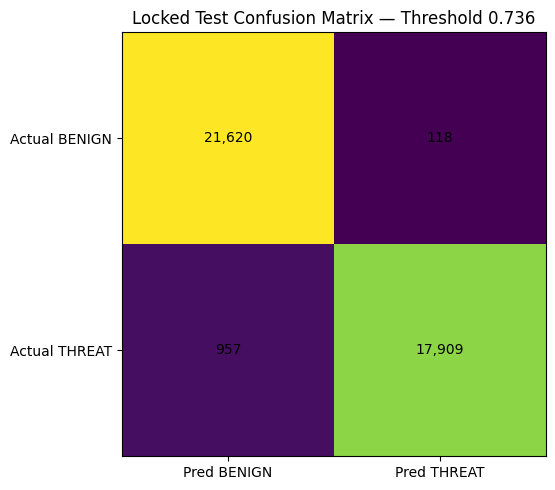

In [37]:
# Cell 37 — Test confusion matrix

test_tn, test_fp, test_fn, test_tp = confusion_matrix(
    y_test,
    test_prediction,
).ravel()

test_matrix = np.array([
    [test_tn, test_fp],
    [test_fn, test_tp],
])

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(test_matrix)

ax.set_xticks([0, 1], labels=["Pred BENIGN", "Pred THREAT"])
ax.set_yticks([0, 1], labels=["Actual BENIGN", "Actual THREAT"])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{test_matrix[i, j]:,}",
            ha="center",
            va="center",
        )

ax.set_title(
    f"Locked Test Confusion Matrix — Threshold {SELECTED_THRESHOLD:.3f}"
)

plt.tight_layout()
plt.show()

## 15.1 Locked Test Per-Source Performance

The final benchmark should also verify generalization across the source corpora.

In [44]:
# Cell 38 — Test per-source performance

test_analysis = test_df.copy()

test_analysis["threat_probability"] = test_probability
test_analysis["prediction_selected"] = test_prediction

def evaluate_test_group(group):
    y_true = group["label_id"].to_numpy()
    y_pred = group["prediction_selected"].to_numpy()
    y_prob = group["threat_probability"].to_numpy()

    result = {
        "rows": len(group),
        "threat_rate": y_true.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if len(np.unique(y_true)) == 2:
        result["roc_auc"] = roc_auc_score(y_true, y_prob)
        result["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        result["roc_auc"] = np.nan
        result["pr_auc"] = np.nan

    security = security_metrics(y_true, y_pred)
    result["false_positive_rate"] = security["false_positive_rate"]
    result["false_negative_rate"] = security["false_negative_rate"]

    return pd.Series(result)


test_source_performance = (
    test_analysis
    .groupby("source_dataset", group_keys=False)
    .apply(
        evaluate_test_group,
        include_groups=False,
    )
    .sort_values("f1", ascending=False)
)

test_source_performance.round(4)

,rows,threat_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,false_negative_rate
source_dataset,,,,,,,,,,
CEAS-08,8004.0,0.5592,0.9931,0.9957,0.9920,0.9938,0.9996,0.9997,0.0054,0.0080
Enron,5918.0,0.4681,0.9743,0.9973,0.9477,0.9719,0.9989,0.9988,0.0022,0.0523
TREC-07,10793.0,0.5435,0.9652,0.9975,0.9383,0.9670,0.9992,0.9993,0.0028,0.0617
TREC-05,10814.0,0.4174,0.9677,0.9867,0.9353,0.9603,0.9968,0.9955,0.0090,0.0647
TREC-06,3287.0,0.2373,0.9772,0.9876,0.9154,0.9501,0.9971,0.9933,0.0036,0.0846
Assassin,1220.0,0.3008,0.9615,0.9678,0.9019,0.9337,0.9954,0.9890,0.0129,0.0981
Ling,568.0,0.1637,0.9630,0.9865,0.7849,0.8743,0.9929,0.9736,0.0021,0.2151


# 16. Save Model Artifacts

The baseline artifacts include:

- complete scikit-learn Pipeline,
- selected operating threshold,
- validation metrics,
- locked-test metrics,
- model configuration,
- source-level test performance.

The Git repository should normally avoid committing large generated model binaries if `artifacts/` is ignored by Git.

In [40]:
# Cell 39 — Persist model and evaluation metadata

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "ml_baseline"
ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_PATH = ARTIFACT_DIR / "tfidf_logistic_regression.joblib"
METRICS_PATH = ARTIFACT_DIR / "metrics.json"
SOURCE_METRICS_PATH = ARTIFACT_DIR / "test_source_metrics.csv"

joblib.dump(
    baseline_model,
    MODEL_PATH,
)

metrics_payload = {
    "model": "TF-IDF + Logistic Regression",
    "selected_threshold": SELECTED_THRESHOLD,
    "target_validation_recall": TARGET_RECALL,
    "tfidf_config": TFIDF_CONFIG,
    "logistic_regression_config": LOGISTIC_CONFIG,
    "validation_default_threshold_0_5": {
        key: float(value)
        for key, value in validation_metrics_05.items()
    },
    "validation_selected_threshold": {
        key: float(value)
        for key, value in validation_metrics_selected.items()
    },
    "test_metrics": {
        key: float(value)
        for key, value in test_metrics.items()
    },
    "test_security_metrics": {
        key: (
            int(value)
            if key in {
                "true_negative",
                "false_positive",
                "false_negative",
                "true_positive",
            }
            else float(value)
        )
        for key, value in test_security.items()
    },
}

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metrics_payload,
        file,
        indent=2,
    )

test_source_performance.to_csv(
    SOURCE_METRICS_PATH
)

print("Saved model         :", MODEL_PATH)
print("Saved metrics       :", METRICS_PATH)
print("Saved source metrics:", SOURCE_METRICS_PATH)

Saved model         : /content/artifacts/ml_baseline/tfidf_logistic_regression.joblib
Saved metrics       : /content/artifacts/ml_baseline/metrics.json
Saved source metrics: /content/artifacts/ml_baseline/test_source_metrics.csv


# 17. Baseline Inference Function

Expose the model through a small inference helper.

This is not yet the production API.

Later it will be wrapped by FastAPI and consumed by the Agentic AI orchestration layer.

In [41]:
# Cell 40 — Baseline inference helper

def classify_email(
    subject: str,
    body: str,
    threshold: float = SELECTED_THRESHOLD,
):
    combined_text = (
        f"{subject}\n\n{body}"
        if subject
        else body
    )

    probability = float(
        baseline_model.predict_proba(
            [combined_text]
        )[0, 1]
    )

    label_id = int(
        probability >= threshold
    )

    label = (
        "THREAT"
        if label_id == 1
        else "BENIGN"
    )

    return {
        "classification": label,
        "label_id": label_id,
        "threat_probability": round(
            probability,
            4,
        ),
        "threshold": round(
            threshold,
            4,
        ),
    }

In [42]:
# Cell 41 — Demonstration inference

example_benign = classify_email(
    subject="Project status meeting",
    body=(
        "Hi team, please find the updated agenda for tomorrow's "
        "project status meeting. Regards, Alex."
    ),
)

example_suspicious = classify_email(
    subject="URGENT: Verify your account",
    body=(
        "Your account will be suspended. Verify your password "
        "immediately using the link provided."
    ),
)

print("Benign-like example:")
print(example_benign)

print("\nSuspicious example:")
print(example_suspicious)

Benign-like example:
{'classification': 'BENIGN', 'label_id': 0, 'threat_probability': 0.0219, 'threshold': 0.7364}

Suspicious example:
{'classification': 'THREAT', 'label_id': 1, 'threat_probability': 0.9842, 'threshold': 0.7364}


# 18. Findings and Modeling Implications

The TF-IDF + Logistic Regression experiment establishes a strong and reproducible classical machine-learning baseline for the Intelligent Spam Classification & Threat Triage Platform.

The results also demonstrate why aggregate classification performance alone is insufficient for an enterprise security system.

---

## 18.1 Baseline Performance

At the default decision threshold of `0.50`, the validation set achieved:

| Metric | Result |
|---|---:|
| Accuracy | 98.26% |
| THREAT Precision | 97.89% |
| THREAT Recall | 98.38% |
| THREAT F1 | 98.13% |
| ROC-AUC | 99.82% |
| PR-AUC | 99.79% |

The default threshold produced:

- **320 false positives**
- **245 false negatives**

This demonstrates that a relatively simple TF-IDF + Logistic Regression model provides a very strong benchmark for this dataset.

However, the objective of this project is not simply to maximize aggregate classification accuracy. For enterprise threat detection, the operational costs of false positives and false negatives are different and must be evaluated explicitly.

---

## 18.2 Operating Threshold Selection

Rather than assuming that `0.50` is the correct production threshold, the validation set was used to evaluate the precision/recall trade-off.

The baseline policy was:

> Select the threshold that achieves at least 95% THREAT recall while maximizing precision.

This resulted in:

**Selected threshold: `0.7364`**

At this threshold, validation performance was:

| Metric | Result |
|---|---:|
| Accuracy | 97.35% |
| Precision | 99.25% |
| Recall | 95.02% |
| F1 | 97.09% |
| False Positive Rate | 0.63% |
| False Negative Rate | 4.98% |

The threshold change illustrates an important security trade-off.

At threshold `0.50`:

- False Positives = **320**
- False Negatives = **245**

At threshold `0.7364`:

- False Positives = **109**
- False Negatives = **752**

Therefore, increasing the threshold eliminated approximately **211 false positives**, but introduced approximately **507 additional false negatives**.

This demonstrates that threshold selection is fundamentally a **risk-policy decision**, not simply a model-optimization decision.

In a production security platform, the operating threshold should eventually incorporate business cost, analyst capacity, quarantine policy, threat severity, and human-review requirements.

---

## 18.3 Locked Test Performance

After the operating threshold was selected using validation data, the previously untouched test set was evaluated exactly once.

The locked test set achieved:

| Metric | Result |
|---|---:|
| Accuracy | **97.35%** |
| THREAT Precision | **99.35%** |
| THREAT Recall | **94.93%** |
| THREAT F1 | **97.09%** |
| ROC-AUC | **99.84%** |
| PR-AUC | **99.81%** |
| False Positive Rate | **0.54%** |
| False Negative Rate | **5.07%** |
| Specificity | **99.46%** |

The locked-test confusion matrix contained:

- True Negatives: **21,620**
- False Positives: **118**
- False Negatives: **957**
- True Positives: **17,909**

The close agreement between validation and locked-test results indicates that the baseline generalizes well to the supplied test split.

---

## 18.4 Aggregate Metrics Hide Source-Level Risk

Although aggregate test performance is excellent, per-source evaluation revealed materially different behavior across the underlying email corpora.

Approximate THREAT recall by source was:

| Source Dataset | THREAT Recall | False Negative Rate |
|---|---:|---:|
| CEAS-08 | 99.20% | 0.80% |
| Enron | 94.77% | 5.23% |
| TREC-07 | 93.83% | 6.17% |
| TREC-05 | 93.53% | 6.47% |
| TREC-06 | 91.54% | 8.46% |
| Assassin | 90.19% | 9.81% |
| **Ling** | **78.49%** | **21.51%** |

The most significant result is the **Ling false-negative rate of 21.51%**.

This means that a model reporting approximately 97% aggregate accuracy can still perform substantially worse on a particular data distribution.

For an enterprise security system, this is a critical observation.

Model evaluation must therefore include:

- aggregate metrics,
- source/domain-level metrics,
- false-positive and false-negative analysis,
- distribution-shift monitoring,
- and eventually production drift detection.

---

## 18.5 False-Negative Analysis

The false-negative analysis revealed another important limitation.

Some messages labeled as THREAT received extremely low threat probabilities, including values approximately:

```text
0.0064
0.0091
0.0191
0.0273

## 18.6 Explainability and Shortcut-Learning Risk

Logistic Regression coefficient analysis provides useful **global model explainability**.

The strongest THREAT-associated features included terms such as:

**`http`, `money`, `meds`, `pills`, `viagra`, `offer`, `cialis`, `product`, `weight`**

These features are intuitively consistent with spam, phishing, suspicious promotional content, or other unwanted email.

However, several influential THREAT-associated features were less obviously related to malicious intent:

**`2005`, `2004`, `enron com`, `hk`, `he`, `her`, `his`**

Similarly, strongly BENIGN-associated features included:

**`thanks`, `wrote`, `enron`, `713`, `2001`, `2002`, `2007`, `perl`, `vince`, `opensuse`, `meeting`, `university`**

Several of these terms appear related to a particular source corpus, organization, historical period, mailing list, or communication style rather than universally BENIGN or THREAT behavior.

### Key Observation

The classifier therefore appears to be learning two types of information simultaneously:

1. **Genuine lexical indicators** associated with spam or threat content.
2. **Dataset/source-specific characteristics** associated with the underlying historical corpora.

This creates a potential **shortcut-learning / source-bias risk**.

Conceptually, the model may partly be learning:

> **"This message resembles a particular historical dataset."**

rather than exclusively learning:

> **"This message contains suspicious or malicious intent."**

This does not invalidate the baseline results, but it highlights an important generalization risk.

A production system should therefore evaluate performance across domains and distributions rather than relying exclusively on aggregate test-set performance.

---

## 18.7 Why High ROC-AUC Is Not Sufficient

The locked-test ROC-AUC is **99.84%**, which represents excellent aggregate discrimination performance.

However, the source-level analysis showed:

| Source Dataset | False Negative Rate |
|---|---:|
| CEAS-08 | 0.80% |
| Enron | 5.23% |
| TREC-07 | 6.17% |
| TREC-05 | 6.47% |
| TREC-06 | 8.46% |
| Assassin | 9.81% |
| **Ling** | **21.51%** |

In addition, several false-negative examples received extremely low predicted threat probabilities.

Therefore:

> **A high global ROC-AUC does not imply uniformly safe operational performance.**

Enterprise security evaluation must consider multiple dimensions:

- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC
- False Positive Rate
- False Negative Rate
- Per-source performance
- Threshold behavior
- Error analysis
- Model explainability
- Distribution shift and model drift

This is particularly important in cybersecurity because a relatively small number of confidently missed threats can have significantly greater business impact than the aggregate metric suggests.

---

## 18.8 Architectural Implication

The classical ML classifier should **not become the final security decision authority**.

Instead, it should become one evidence-producing component within the larger Intelligent Spam Classification & Threat Triage Platform.

The target architecture evolves toward:

    Incoming Email
          │
          ▼
    Canonical Data Layer
          │
          ▼
    TF-IDF + Logistic Regression
          │
          ▼
    ML Threat Probability
          │
          ▼
    Security Evidence Layer
          │
          ├── URL / Domain Signals
          ├── Sender / Header Signals
          ├── Authentication Signals
          └── Threat Intelligence
          │
          ▼
    Agentic Analysis
    Google ADK + Gemini
          │
          ▼
    Evidence Aggregation
          │
          ▼
    Risk Score / Triage Decision
          │
          ├───────────────┐
          ▼               ▼
    Automated Action   Human Review
                         (HITL)

The classical model provides a fast statistical signal, while deterministic security analysis and semantic reasoning provide additional evidence before a final decision is made.

This architecture allows the platform to combine:

**Statistical ML + Security Domain Signals + LLM Reasoning + Human Oversight**

rather than relying on any single detection mechanism.

---

## 18.9 ML Confidence Alone Must Not Control Agent Routing

A simple hybrid architecture might route only predictions close to `P(THREAT) = 0.50` to Gemini or an Agentic AI workflow.

For example:

**Low probability → BENIGN**

**Middle probability → Gemini**

**High probability → THREAT**

The false-negative analysis demonstrates why this approach is insufficient.

Some actual THREAT messages received probabilities approximately:

**0.0064, 0.0091, 0.0191, 0.0273**

These are not uncertain predictions.

They are **high-confidence incorrect predictions**.

Therefore:

> **ML uncertainty alone cannot determine whether deeper security analysis is required.**

The future routing policy should combine multiple signals:

    ML Threat Probability
              +
    URL / Domain Evidence
              +
    Sender / Authentication Evidence
              +
    Message Characteristics
              +
    Threat Intelligence
              +
    Distribution / Drift Indicators
              ↓
        Agent Routing Policy

Conceptually, deeper analysis may be triggered when:

- ML uncertainty is high → **Agentic Analysis**
- suspicious URL/domain evidence exists → **Agentic Analysis**
- sender/authentication evidence conflicts with ML → **Agentic Analysis**
- message appears out-of-distribution → **Agentic Analysis**
- security policy requires additional verification → **Agentic Analysis**
- risk exceeds an escalation threshold → **Human Review**

This creates a **multi-signal routing policy** rather than a simple probability-based gray zone.

---

## 18.10 Role of the Classical ML Baseline

Despite its limitations, the classical model remains valuable and should remain part of the final platform.

It provides:

- **Fast inference**
- **Deterministic behavior**
- **Low computational cost**
- **Reproducibility**
- **Interpretable global coefficients**
- **Probabilistic threat evidence**
- **A benchmark for future AI components**

Its intended role in the final architecture is therefore:

> ### Fast Statistical Evidence Provider

rather than:

> ### Final Security Decision Authority

This distinction is important.

The ML classifier answers:

> **"Based on statistical patterns learned from historical email text, how likely is this message to belong to the THREAT class?"**

The complete threat-triage platform must answer a broader question:

> **"Considering ML evidence, security indicators, contextual reasoning, threat intelligence, and enterprise policy, what risk does this message represent and what action should be taken?"**

Those are fundamentally different responsibilities.

---

## 18.11 Baseline Conclusion

The TF-IDF + Logistic Regression model is sufficiently strong to become the project's **locked classical ML benchmark**.

The key result is not simply that the classifier achieved high accuracy.

The more important engineering conclusion is:

> **A classical text classifier can provide highly effective first-stage threat detection, but aggregate metrics and model confidence alone are insufficient for enterprise security decisioning.**

The baseline experiment exposed five important limitations and design considerations:

1. **Threshold-dependent security trade-offs** between false positives and false negatives.
2. **Source-specific generalization weaknesses**, including a 21.51% false-negative rate on the Ling corpus.
3. **Confidently incorrect threat predictions**, demonstrating that low ML probability does not always imply low risk.
4. **Potential dataset shortcut learning**, visible through source-specific TF-IDF coefficients.
5. **The need for multi-signal evidence aggregation** before making enterprise security decisions.

These findings provide the technical motivation for the next phase of the platform.

### Next Architecture Evolution

    Classical ML Baseline
            ✓
            │
            ▼
    Security Feature Engineering
            │
            ├── URL / Domain Analysis
            ├── Sender Analysis
            ├── Header / Authentication Signals
            └── Message Security Features
            │
            ▼
    Deterministic Security Evidence
            │
            ▼
    Google ADK + Gemini
            │
            ▼
    Agentic Threat Analysis
            │
            ▼
    Evidence Aggregation
            │
            ▼
    Risk Scoring
            │
            ▼
    Triage Decision
            │
            ▼
    Explainability
            │
            ▼
    Human-in-the-Loop

The future Agentic AI layer will therefore be introduced to address **demonstrated limitations of the baseline**, rather than being added simply for architectural complexity.

This completes the **Classical ML Baseline** phase of the Intelligent Spam Classification & Threat Triage Platform.

# 19. Next Phase

Once this notebook is complete, the classical ML baseline becomes the benchmark for later experiments.

Recommended next implementation sequence:

```text
02_ml_baseline.ipynb
        ↓
baseline metrics locked
        ↓
security feature extraction
        ↓
URL / sender / header intelligence
        ↓
Google ADK orchestration
        ↓
Gemini message intelligence
        ↓
threat evidence agent
        ↓
risk scoring
        ↓
triage decision
        ↓
explainability
        ↓
human-in-the-loop
```

The later portfolio comparison should ultimately show:

| Approach | Purpose |
|---|---|
| ML-only | Fast deterministic baseline |
| Gemini-only | Semantic reasoning benchmark |
| Hybrid ML + Agentic AI | Multi-signal threat decisioning |
| Hybrid + HITL | Enterprise operational architecture |

---

## Notebook Completion Checklist

- [ ] Canonical loader imported successfully
- [ ] Train / validation / test splits verified
- [ ] Split overlap checked
- [ ] TF-IDF configuration documented
- [ ] Logistic Regression trained
- [ ] Validation Accuracy measured
- [ ] Validation Precision measured
- [ ] Validation Recall measured
- [ ] Validation F1 measured
- [ ] Validation ROC-AUC measured
- [ ] Validation PR-AUC measured
- [ ] Validation confusion matrix reviewed
- [ ] False Positive Rate calculated
- [ ] False Negative Rate calculated
- [ ] Per-source validation performance reviewed
- [ ] False positives inspected
- [ ] False negatives inspected
- [ ] Strongest THREAT features reviewed
- [ ] Strongest BENIGN features reviewed
- [ ] Threshold trade-offs analyzed
- [ ] Operating threshold selected using validation only
- [ ] Locked test evaluated exactly after threshold selection
- [ ] Per-source locked-test performance reviewed
- [ ] Model artifact saved
- [ ] Evaluation metrics saved
- [ ] Inference helper tested
- [ ] Findings section updated from actual outputs

Once these checks are complete, this notebook becomes the **classical ML baseline benchmark** for the project.